<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PR_PRACTICAL_5_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_transactions.xlsx to customer_transactions.xlsx


In [6]:
import os

print(os.listdir())

['.config', 'customer_transactions.xlsx', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_excel("customer_transactions.xlsx")

df.head()

,CustomerID,Age,Annual Income,Spending Score,Total Purchase
0,1,22,18,25,1200
1,2,25,22,35,1800
2,3,28,25,40,2200
3,4,32,30,45,2600
4,5,35,35,50,3000


In [8]:
!pip install openpyxl

In [9]:
import pandas as pd

df = pd.read_excel("customer_transactions.xlsx")
df.head()

,CustomerID,Age,Annual Income,Spending Score,Total Purchase
0,1,22,18,25,1200
1,2,25,22,35,1800
2,3,28,25,40,2200
3,4,32,30,45,2600
4,5,35,35,50,3000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      20 non-null     int64
 1   Age             20 non-null     int64
 2   Annual Income   20 non-null     int64
 3   Spending Score  20 non-null     int64
 4   Total Purchase  20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


In [11]:
df.describe()

,CustomerID,Age,Annual Income,Spending Score,Total Purchase
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,36.900000,63.150000,58.200000,4085.000000
std,5.91608,9.233235,28.908704,26.658859,2221.491912
min,1.00000,22.000000,18.000000,20.000000,1200.000000
25%,5.75000,29.500000,42.500000,33.750000,1950.000000
50%,10.50000,37.000000,62.500000,60.000000,4100.000000
75%,15.25000,44.250000,86.250000,82.750000,6125.000000
max,20.00000,52.000000,110.000000,95.000000,7200.000000


In [12]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Annual Income,0
Spending Score,0
Total Purchase,0


In [13]:
X = df[['Annual Income','Spending Score']]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

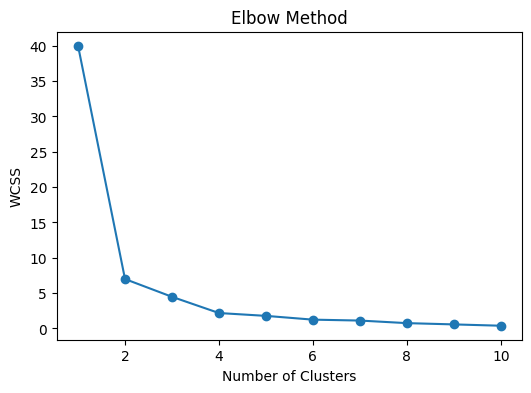

In [16]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

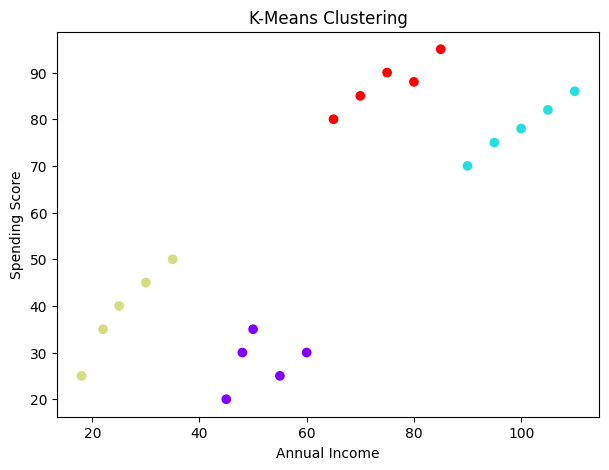

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(df['Annual Income'],
            df['Spending Score'],
            c=df['KMeans_Cluster'],
            cmap='rainbow')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

In [19]:
linked = linkage(X_scaled, method='ward')

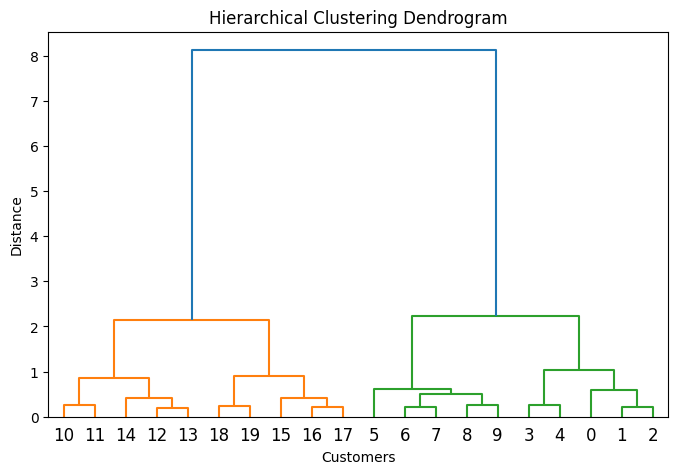

In [20]:
plt.figure(figsize=(8,5))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [21]:
hc = AgglomerativeClustering(n_clusters=4)

df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

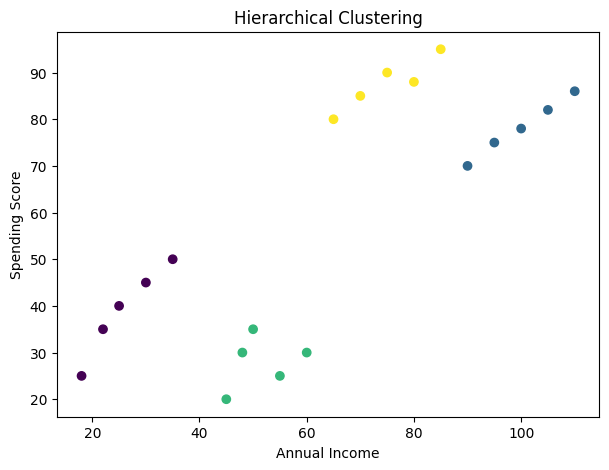

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(df['Annual Income'],
            df['Spending Score'],
            c=df['Hierarchical_Cluster'],
            cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering")
plt.show()

In [23]:
df[['Annual Income',
    'Spending Score',
    'KMeans_Cluster',
    'Hierarchical_Cluster']].head(10)

,Annual Income,Spending Score,KMeans_Cluster,Hierarchical_Cluster
0,18,25,2,0
1,22,35,2,0
2,25,40,2,0
3,30,45,2,0
4,35,50,2,0
5,45,20,0,2
6,48,30,0,2
7,50,35,0,2
8,55,25,0,2
9,60,30,0,2
